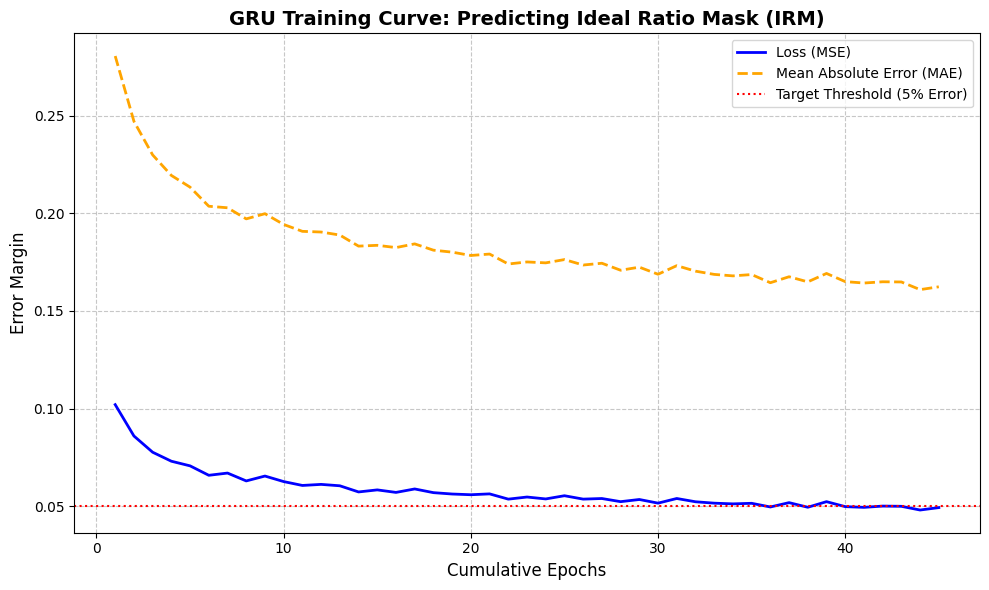

Total Epochs Trained: 45
Final MSE: 0.0493
Final MAE: 0.1624


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the training logs
csv_path = 'training_history.csv'
try:
    history_df = pd.read_csv(csv_path)
except FileNotFoundError:
    print(f"Error: {csv_path} not found.")
    raise

# 2. Extract metrics and override the epoch column
# This creates a continuous array from 1 to the total number of recorded epochs (e.g., 1 to 45)
epochs = range(1, len(history_df) + 1) 
mse_loss = history_df['loss']
mae = history_df['mae']

# 3. Plotting the Learning Curve
plt.figure(figsize=(10, 6))

plt.plot(epochs, mse_loss, label='Loss (MSE)', color='blue', linewidth=2)
plt.plot(epochs, mae, label='Mean Absolute Error (MAE)', color='orange', linewidth=2, linestyle='--')

# 4. Formatting
plt.title('GRU Training Curve: Predicting Ideal Ratio Mask (IRM)', fontsize=14, fontweight='bold')
plt.xlabel('Cumulative Epochs', fontsize=12)
plt.ylabel('Error Margin', fontsize=12)
plt.axhline(y=0.05, color='red', linestyle=':', label='Target Threshold (5% Error)')

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()

# 5. Save and display
plt.savefig('learning_curve.png', dpi=300)
plt.show()

print(f"Total Epochs Trained: {len(history_df)}")
print(f"Final MSE: {mse_loss.iloc[-1]:.4f}")
print(f"Final MAE: {mae.iloc[-1]:.4f}")

/home/tech_adnan/noise_project/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_25628/1645498514.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


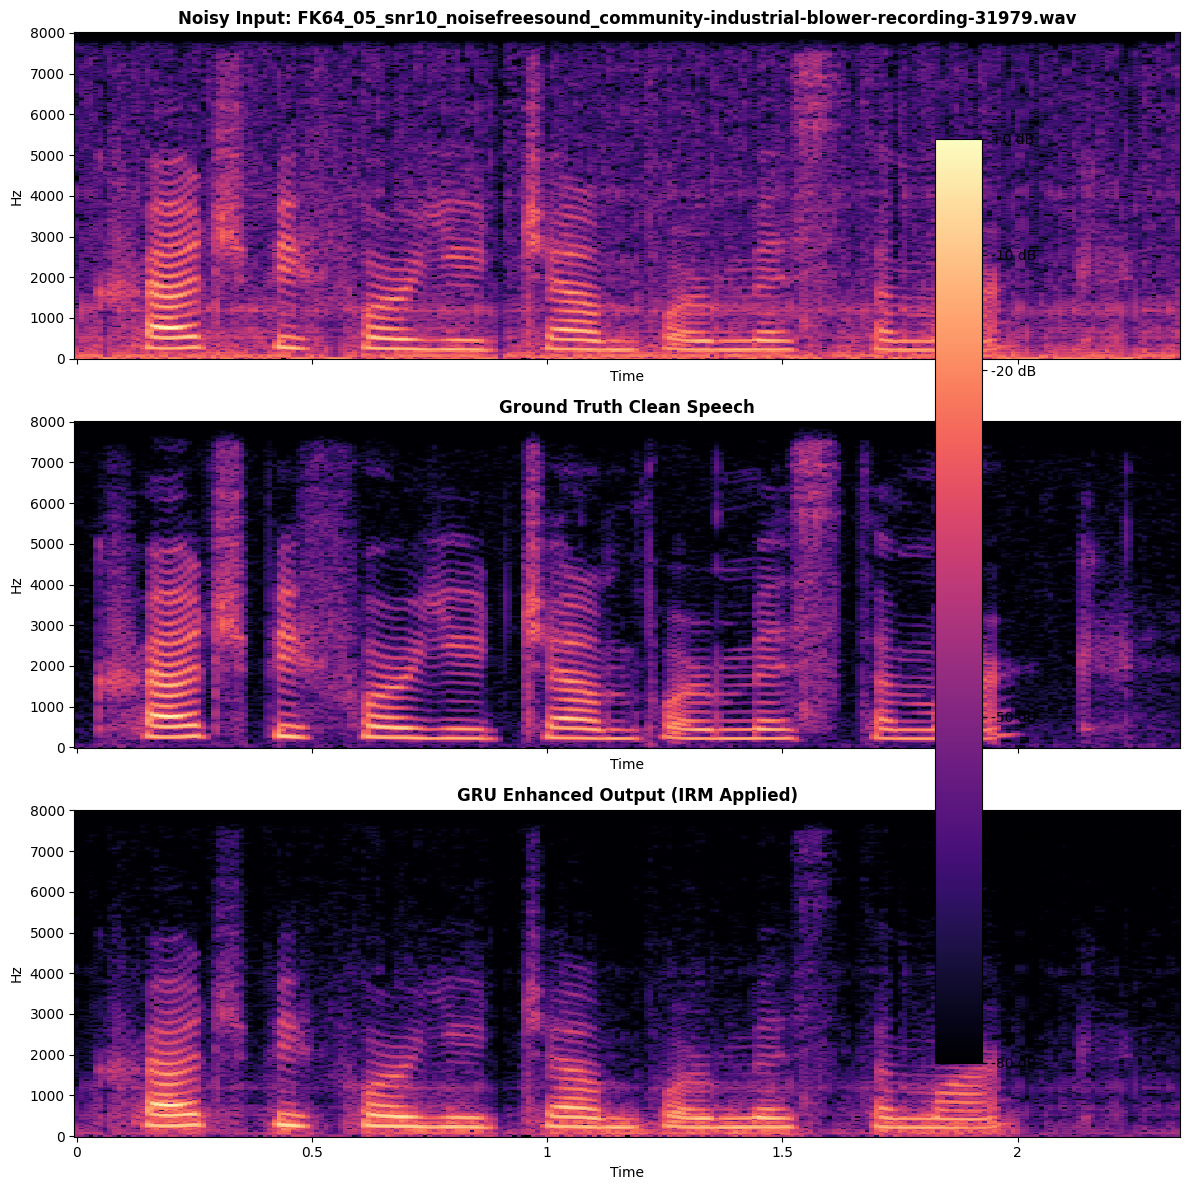

In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# 1. Define paths based on Phase 3 output
comp_dir = Path('comparing')
noisy_files = list(comp_dir.glob('noisy_*.wav'))

if not noisy_files:
    print("Error: No files found in the 'comparing' directory. Ensure Phase 3 inference ran successfully.")
else:
    # 2. Extract base filename from the first available file
    base_name = noisy_files[0].name.replace('noisy_', '')
    
    noisy_path = comp_dir / f"noisy_{base_name}"
    clean_path = comp_dir / f"clean_{base_name}"
    enhanced_path = comp_dir / f"enhanced_{base_name}"
    
    # 3. Load audio arrays
    sr = 16000
    y_noisy, _ = librosa.load(noisy_path, sr=sr)
    y_enhanced, _ = librosa.load(enhanced_path, sr=sr)
    
    has_clean = clean_path.exists()
    if has_clean:
        y_clean, _ = librosa.load(clean_path, sr=sr)

    # 4. Compute STFT and convert to Log-Magnitude (dB)
    # Using your exact Phase 2 parameters
    n_fft = 512
    hop_length = 160
    
    D_noisy = librosa.amplitude_to_db(np.abs(librosa.stft(y_noisy, n_fft=n_fft, hop_length=hop_length)), ref=np.max)
    D_enhanced = librosa.amplitude_to_db(np.abs(librosa.stft(y_enhanced, n_fft=n_fft, hop_length=hop_length)), ref=np.max)
    
    if has_clean:
        D_clean = librosa.amplitude_to_db(np.abs(librosa.stft(y_clean, n_fft=n_fft, hop_length=hop_length)), ref=np.max)

    # 5. Plotting Architecture
    n_plots = 3 if has_clean else 2
    fig, axes = plt.subplots(n_plots, 1, figsize=(12, 4 * n_plots), sharex=True, sharey=True)
    
    # Handle matplotlib axes array indexing
    if not has_clean: axes = [axes[0], None, axes[1]]
    
    # Plot Noisy
    img = librosa.display.specshow(D_noisy, y_axis='linear', x_axis='time', sr=sr, hop_length=hop_length, ax=axes[0])
    axes[0].set_title(f'Noisy Input: {base_name}', fontweight='bold')
    
    # Plot Clean (Ground Truth)
    if has_clean:
        librosa.display.specshow(D_clean, y_axis='linear', x_axis='time', sr=sr, hop_length=hop_length, ax=axes[1])
        axes[1].set_title('Ground Truth Clean Speech', fontweight='bold')
        
    # Plot Enhanced
    ax_enh = axes[2] if has_clean else axes[1]
    librosa.display.specshow(D_enhanced, y_axis='linear', x_axis='time', sr=sr, hop_length=hop_length, ax=ax_enh)
    ax_enh.set_title('GRU Enhanced Output (IRM Applied)', fontweight='bold')
    
    # Formatting
    fig.colorbar(img, ax=axes if has_clean else [axes[0], axes[2]], format="%+2.0f dB")
    plt.tight_layout()
    
    # Save high-resolution artifact for your report
    plt.savefig('spectrogram_comparison.png', dpi=300)
    plt.show()

In [2]:
import numpy as np
import pandas as pd
import librosa
from pathlib import Path
from pesq import pesq
from pystoi import stoi

comp_dir = Path('comparing')
clean_files = list(comp_dir.glob('clean_*.wav'))

if not clean_files:
    print("Error: No clean ground truth files found in 'comparing' directory.")
else:
    results = []
    sr_target = 16000 # pesq strictly requires 16kHz or 8kHz
    
    for clean_path in clean_files:
        base_name = clean_path.name.replace('clean_', '')
        noisy_path = comp_dir / f"noisy_{base_name}"
        enhanced_path = comp_dir / f"enhanced_{base_name}"
        
        if not (noisy_path.exists() and enhanced_path.exists()):
            continue
            
        # Load audio
        clean, _ = librosa.load(clean_path, sr=sr_target)
        noisy, _ = librosa.load(noisy_path, sr=sr_target)
        enhanced, _ = librosa.load(enhanced_path, sr=sr_target)
        
        # Ensure identical lengths for metric functions
        min_len = min(len(clean), len(noisy), len(enhanced))
        clean = clean[:min_len]
        noisy = noisy[:min_len]
        enhanced = enhanced[:min_len]
        
        # Compute STOI
        stoi_noisy = stoi(clean, noisy, sr_target, extended=False)
        stoi_enhanced = stoi(clean, enhanced, sr_target, extended=False)
        
        # Compute PESQ (Wideband)
        try:
            pesq_noisy = pesq(sr_target, clean, noisy, 'wb')
            pesq_enhanced = pesq(sr_target, clean, enhanced, 'wb')
        except Exception as e:
            # PESQ can fail if the audio is completely silent or pure noise
            pesq_noisy, pesq_enhanced = np.nan, np.nan
            
        results.append({
            'Filename': base_name,
            'PESQ (Noisy)': pesq_noisy,
            'PESQ (Enhanced)': pesq_enhanced,
            'PESQ Improvement': pesq_enhanced - pesq_noisy,
            'STOI (Noisy)': stoi_noisy,
            'STOI (Enhanced)': stoi_enhanced,
            'STOI Improvement': stoi_enhanced - stoi_noisy
        })

    # Compile and display report
    df_results = pd.DataFrame(results)
    
    print("=== Objective Audio Evaluation Report ===")
    display(df_results.round(3))
    
    print("\n=== Mean Dataset Metrics ===")
    print(df_results[['PESQ (Noisy)', 'PESQ (Enhanced)', 'STOI (Noisy)', 'STOI (Enhanced)']].mean().round(3))
    
    # Save to CSV for your final document
    df_results.to_csv('objective_metrics_report.csv', index=False)

=== Objective Audio Evaluation Report ===


,Filename,PESQ (Noisy),PESQ (Enhanced),PESQ Improvement,STOI (Noisy),STOI (Enhanced),STOI Improvement
0,FK64_05_snr10_noisefreesound_community-industr...,1.479,1.458,-0.020,0.938,0.939,0.001
1,FE29_06_snr15_noisefreesound_community-compute...,1.507,1.772,0.265,0.967,0.945,-0.022



=== Mean Dataset Metrics ===
PESQ (Noisy)       1.493
PESQ (Enhanced)    1.615
STOI (Noisy)       0.953
STOI (Enhanced)    0.942
dtype: float64
